In [2]:
from miss_alignment.data.io import read_tomogram_from_pickle
from copy import deepcopy
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

In [3]:
sns.set(style='ticks', context='talk')

graph for model_0


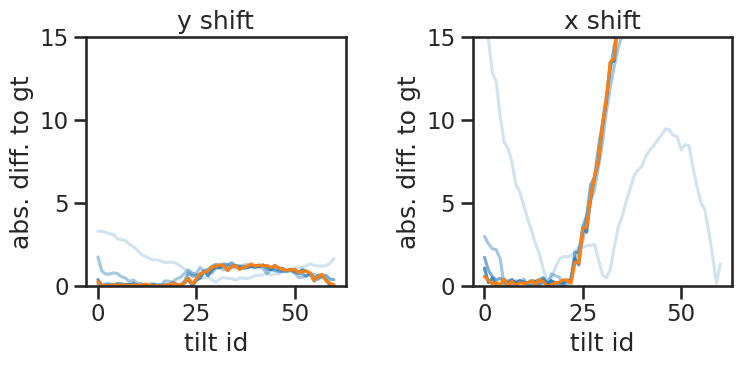

graph for model_1


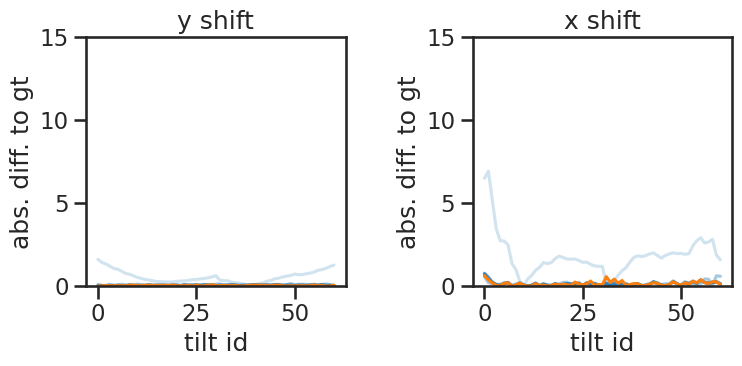

graph for model_2


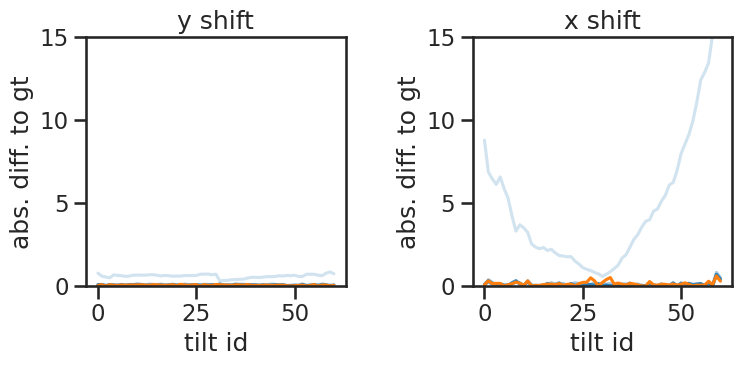

graph for model_3


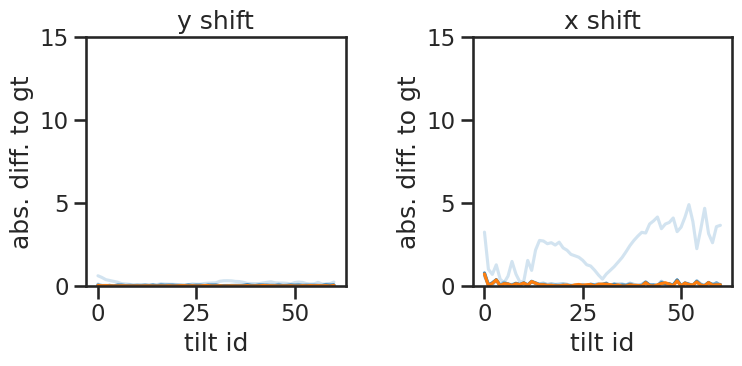

graph for model_4


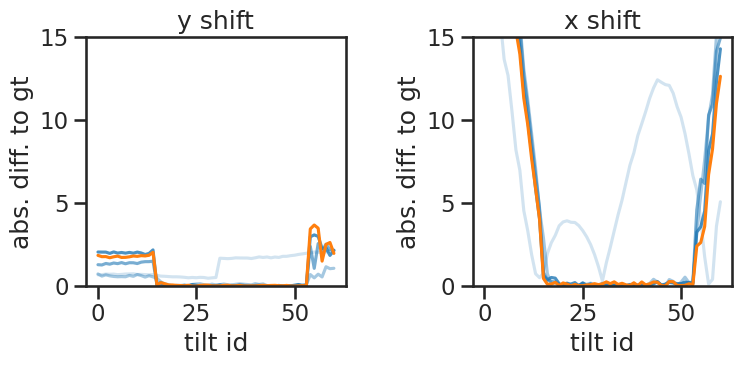

graph for model_5


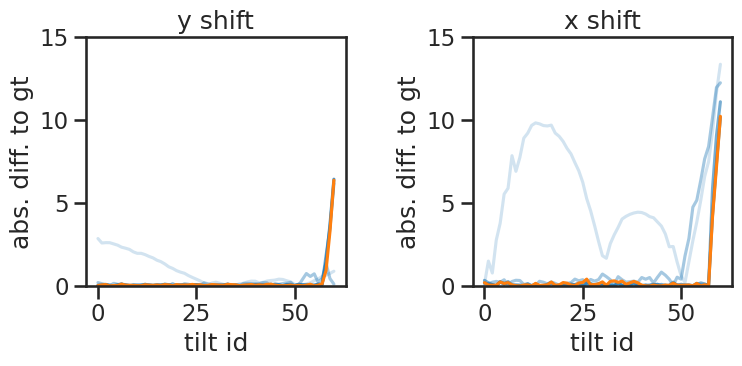

graph for model_6


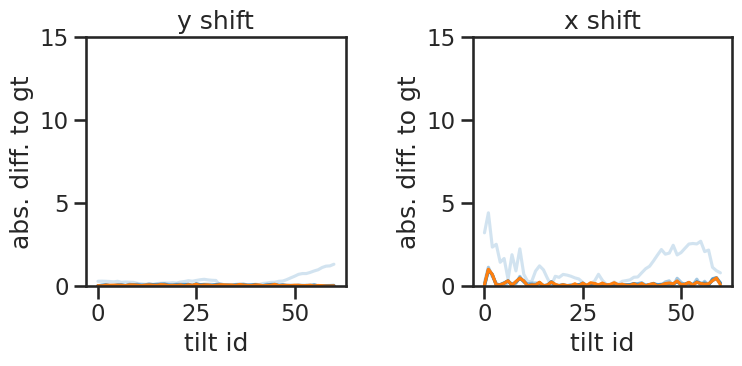

graph for model_7


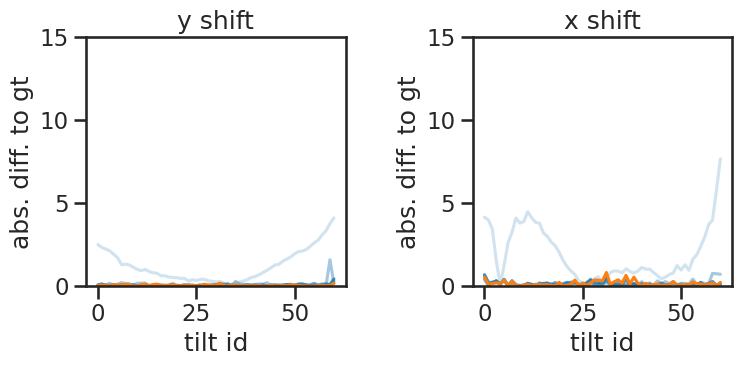

graph for model_8


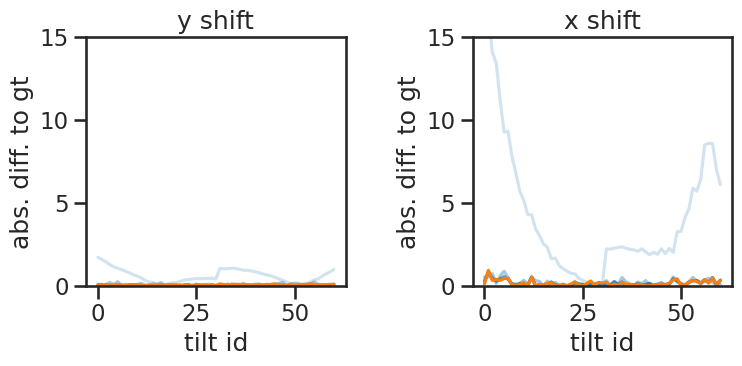

graph for model_9


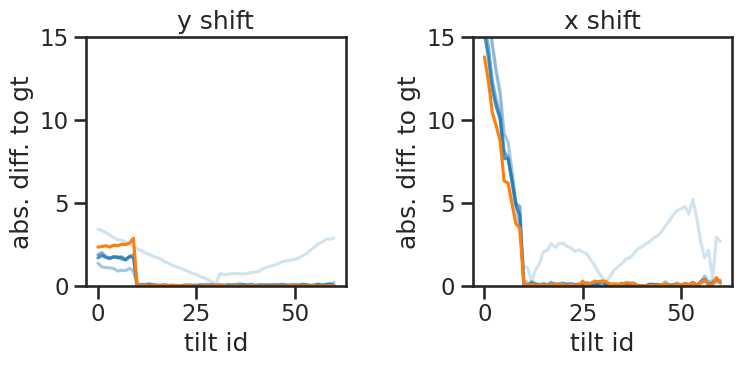

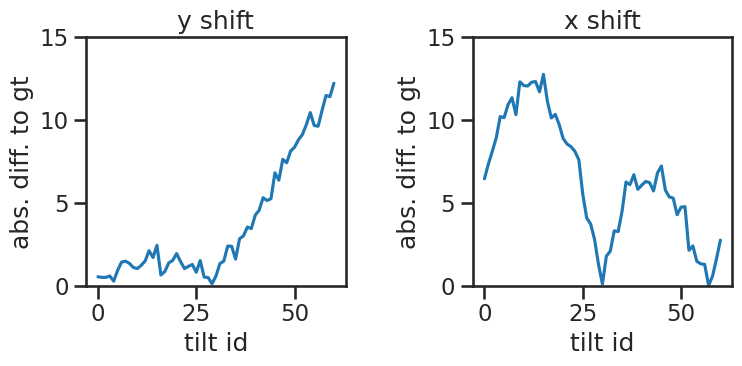

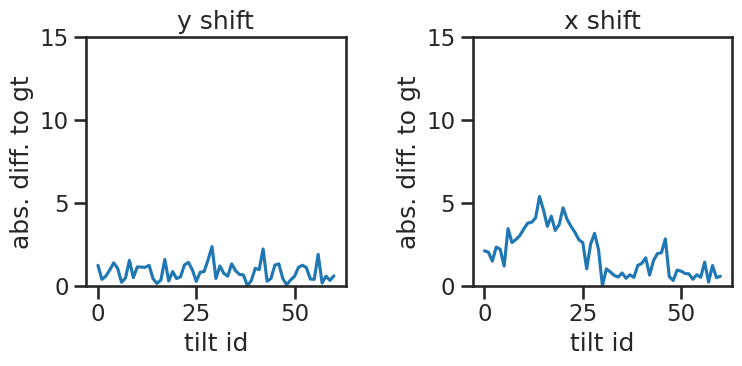

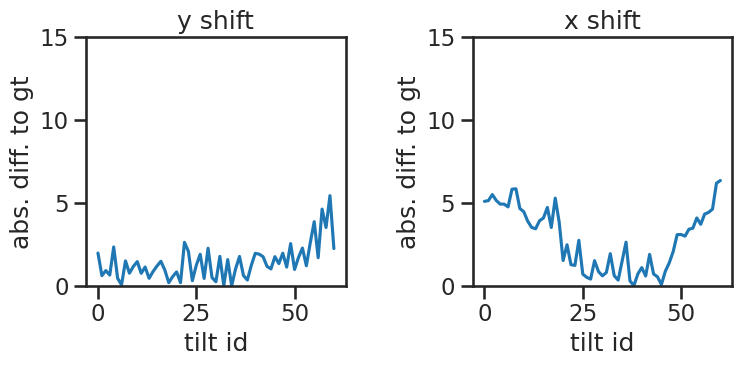

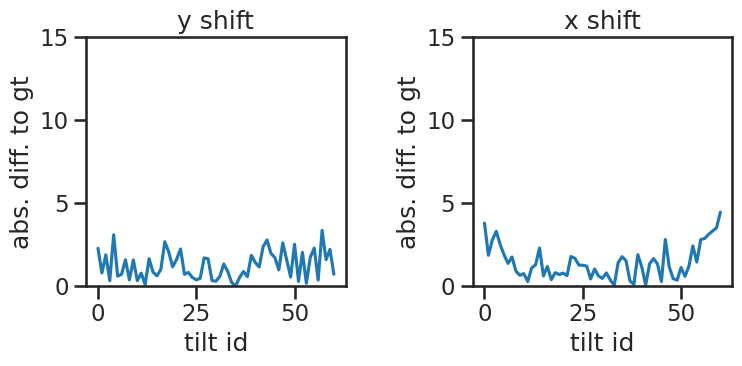

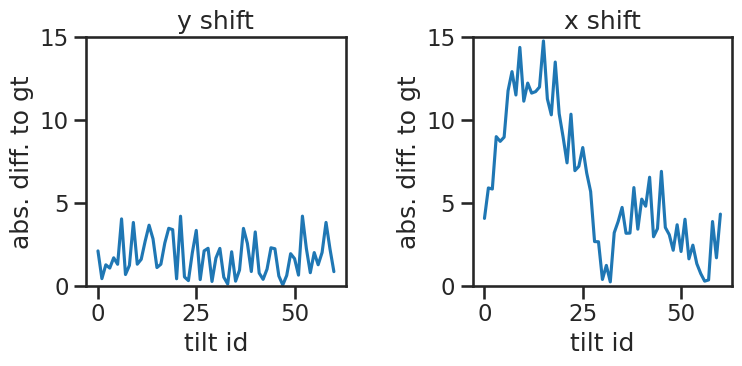

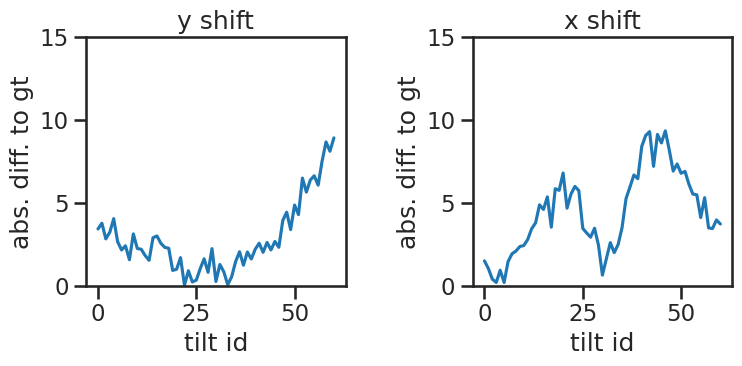

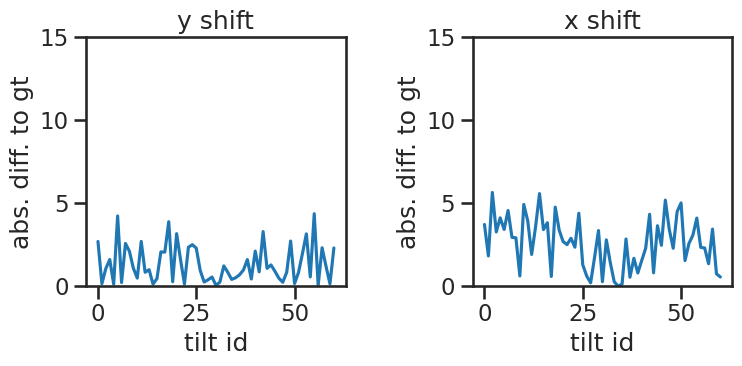

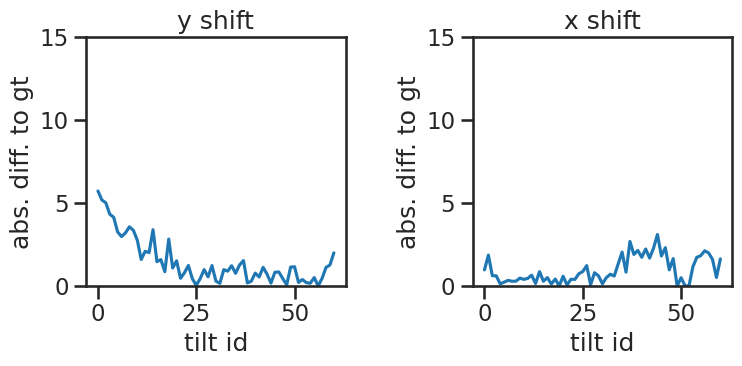

In [ ]:
TOMO_SHAPE = (128, 256, 256)

def read_aretomo_alignment(filepath):
    with open(filepath) as fstream:
        data = fstream.readlines()
    data = [d.strip().split() for d in data if not d.startswith('#')]
    data = torch.tensor([[float(d[4]), float(d[3])] for d in data])
    return data

def center_tomogram(tilt_series_ground_truth, tilt_series):
    from miss_alignment.alignment.tilt_series import calculate_cross_correlation, get_shift_from_correlation_image
    from miss_alignment.data.shift_generation import project_shifts_3d_to_2d
    n_tilts = len(tilt_series.tilt_angles)
    ground_truth_reconstruction = tilt_series_ground_truth.reconstruct_tomogram(
        TOMO_SHAPE, 128
    )

    aligned_reconstruction = tilt_series.reconstruct_tomogram(TOMO_SHAPE, 128)

    correlation = calculate_cross_correlation(
        ground_truth_reconstruction, aligned_reconstruction
    )
    shift_3d = get_shift_from_correlation_image(correlation)
    shift_3d = -1 * shift_3d  # get the forward shift for the imaging model
    shift_3d = shift_3d.repeat(n_tilts, 1)

    shifts_2d = project_shifts_3d_to_2d(
        shift_3d, tilt_series.projection_matrices[..., :3, :3]
    )
    tilt_series.sample_translations += shifts_2d
    return tilt_series

results = []
n_iters = 5
experiment = 'run_ablation3'
for x in range(10):
    print(f'graph for model_{x}')
    gt = read_tomogram_from_pickle(f'/data/mchaillet/model_training/shrec/run8/ground_truth/model_{x}.pickle')
    # gt.sample_translations[:, 1] *= torch.cos(torch.deg2rad(gt.tilt_angles))
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    for i in range(0, n_iters):
        tomo = read_tomogram_from_pickle(f'/data/mchaillet/model_training/shrec/{experiment}/iter{i}/model_{x}.pickle')
        abs_diff = torch.abs(gt.sample_translations - tomo.sample_translations)
        for a in abs_diff:
            results.append([x, str(i), a[0].item(), a[1].item()])
        # results.append([x, str(i), torch.mean(abs_diff[:, 0]).item(), torch.mean(abs_diff[:, 1]).item()])
        color = 'tab:blue' if i + 1 < n_iters else 'tab:orange'
        ax[0].plot(
            abs_diff[:, 0], 
            color=color, 
            alpha=(i + 1) / n_iters
        )
        ax[1].plot(
            abs_diff[:, 1], 
            color=color, 
            alpha=(i + 1) / n_iters
        )
    ax[0].set_title('y shift')
    ax[0].set_ylabel('abs. diff. to gt')
    ax[0].set_xlabel('tilt id')
    ax[0].set_ylim(0, 15)
    ax[1].set_title('x shift')
    ax[1].set_ylabel('abs. diff. to gt')
    ax[1].set_xlabel('tilt id')
    ax[1].set_ylim(0, 15)
    plt.tight_layout()
    plt.show()


for x in range(10):
    gt = read_tomogram_from_pickle(f'/data/mchaillet/model_training/shrec/run8/ground_truth/model_{x}.pickle')
    # gt.sample_translations[:, 1] *= torch.cos(torch.deg2rad(gt.tilt_angles))
    at_alignment = read_aretomo_alignment(f'aretomo1_alignment/model_{x}.aln')
    at = deepcopy(gt)
    at.sample_translations = at_alignment
    # at = center_tomogram(gt, at)
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    abs_diff = torch.abs(gt.sample_translations - at.sample_translations)
    for a in abs_diff:
            results.append([x, 'aretomo', a[0].item(), a[1].item()])
    # results.append([x, 'aretomo', torch.mean(abs_diff[:, 0]).item(), torch.mean(abs_diff[:, 1]).item()])
    ax[0].plot(abs_diff[:, 0], color='tab:blue', alpha=(i + 1) / n_iters)
    ax[1].plot(abs_diff[:, 1], color='tab:blue', alpha=(i + 1) / n_iters)
    ax[0].set_title('y shift')
    ax[0].set_ylabel('abs. diff. to gt')
    ax[0].set_xlabel('tilt id')
    ax[0].set_ylim(0, 15)
    ax[1].set_title('x shift')
    ax[1].set_ylabel('abs. diff. to gt')
    ax[1].set_xlabel('tilt id')
    ax[1].set_ylim(0, 15)
    plt.tight_layout()
    plt.show()
        

In [ ]:
data = pd.DataFrame(results, columns=['model', 'iteration', 'abs y diff', 'abs x diff'])

sns.stripplot(data=data, x='iteration', y='abs y diff', legend=False, size=3, alpha=.3)
plt.ylim(-.5,15)
plt.savefig(f'{experiment}_stripplot_abs_y_diff.png', dpi=300, bbox_inches='tight')

In [ ]:
sns.stripplot(data=data, x='iteration', y='abs x diff', legend=False, size=3, alpha=.3)
plt.ylim(-.5,30)
plt.savefig(f'{experiment}_stripplot_abs_x_diff.png', dpi=300, bbox_inches='tight')